Spotify data mining

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')

print("🎵 M3 Spotify Music Clustering - Complete Pipeline")
print("="*60)

🎵 M3 Spotify Music Clustering - Complete Pipeline


1. DATASET GENERATION (Realistic 10K Spotify tracks with M2 issues)

In [10]:
np.random.seed(42)
n_unique_tracks = 8947 # Simulating your true unique tracks
n_duplicates = 1053    # Simulating the multi-genre duplicates

print("\n1. Generating dataset with acoustic_electronic_ratio outliers...")

# Create unique base tracks
df_base = pd.DataFrame({
    'track_id': range(1, n_unique_tracks + 1),
    'danceability': np.random.uniform(0.3, 0.9, n_unique_tracks),
    'energy': np.random.beta(2, 4, n_unique_tracks),  # Skewed LOW → ratio issue
    'acousticness': np.random.beta(3, 2, n_unique_tracks),  # Skewed HIGH
    'valence': np.random.uniform(0.1, 0.9, n_unique_tracks),
    'tempo': np.random.normal(118, 25, n_unique_tracks).clip(60, 200),
    'loudness': np.random.normal(-7, 4, n_unique_tracks).clip(-20, 0),
    'liveness': np.random.uniform(0, 0.3, n_unique_tracks),
    'speechiness': np.random.uniform(0, 0.15, n_unique_tracks),
    'duration_ms': np.random.exponential(220000, n_unique_tracks).clip(30000, 600000),
    'genres': np.random.choice(['rock', 'pop', 'electronic', 'acoustic', 'hiphop', 'r&b'], n_unique_tracks)
})

# Create duplicates to simulate multi-genre overlapping
df_dupes = df_base.sample(n=n_duplicates, random_state=42).copy()
df_dupes['genres'] = np.random.choice(['dance', 'indie', 'folk', 'soul', 'rap'], n_duplicates)

# Combine to create the 10,000 track dataset with duplicates
df = pd.concat([df_base, df_dupes], ignore_index=True)
n_tracks = len(df)

#  FIX M2 ISSUE #1: Create extreme ratio outliers
extreme_mask = np.random.choice(n_tracks, 800, replace=False)
df.loc[extreme_mask, 'energy'] *= 0.03  # Near-zero energy
df.loc[extreme_mask, 'acousticness'] = 0.92

df['acoustic_electronic_ratio'] = np.where(
    df['energy'] > 0.001,
    df['acousticness'] / df['energy'],
    df['acousticness']
)
print(f"BEFORE FIX - Max ratio: {df['acoustic_electronic_ratio'].max():.1f}")


1. Generating dataset with acoustic_electronic_ratio outliers...
BEFORE FIX - Max ratio: 901.2


2. M2 FEEDBACK FIXES IMPLEMENTED

In [11]:
print("\n2. APPLYING M2 FEEDBACK FIXES...")

# FIX #1: Clip + Log transform ratio
upper_clip = df['acoustic_electronic_ratio'].quantile(0.99)
df['ratio_fixed'] = df['acoustic_electronic_ratio'].clip(upper=upper_clip)
df['ratio_log'] = np.log1p(df['ratio_fixed'])
print(f"AFTER FIX - Max log-ratio: {df['ratio_log'].max():.2f}")

# FIX #2: Deduplicate multi-genre tracks properly via track_id
print("\n✅ DEDUPLICATION EXPERIMENT:")
print(f"Total rows before deduplication: {len(df):,}")
df_dedup = df.drop_duplicates(subset='track_id').copy()
print(f"Deduplicated: {len(df_dedup):,} tracks ({100*(1-len(df_dedup)/len(df)):.1f}% reduction)")

# Create the duration norm feature BEFORE referencing it in the features list
df_dedup['duration_norm'] = df_dedup['duration_ms'] / 1000



2. APPLYING M2 FEEDBACK FIXES...
AFTER FIX - Max log-ratio: 5.49

✅ DEDUPLICATION EXPERIMENT:
Total rows before deduplication: 10,000
Deduplicated: 8,947 tracks (10.5% reduction)


3. CLUSTERING WITH VALIDATION (k=2 justification)

In [12]:
features = ['danceability', 'energy', 'valence', 'tempo', 'loudness',
            'liveness', 'speechiness', 'duration_norm', 'ratio_log']

X = df_dedup[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n3. K-MEANS CLUSTERING (k=2 vs k=3-4 comparison)...")
sil_scores, db_scores = [], []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

k_opt_sil = np.argmax(sil_scores) + 2
print(f"Silhouette Peak: k={k_opt_sil} (score: {max(sil_scores):.3f})")
print(f"Davies-Bouldin Min: k={np.argmin(db_scores)+2} (score: {min(db_scores):.3f})")



3. K-MEANS CLUSTERING (k=2 vs k=3-4 comparison)...
Silhouette Peak: k=2 (score: 0.177)
Davies-Bouldin Min: k=2 (score: 2.039)


Final k=2 clustering

In [13]:
kmeans_final = KMeans(2, random_state=42, n_init=10)
df_dedup['cluster'] = kmeans_final.fit_predict(X_scaled)
final_sil = silhouette_score(X_scaled, df_dedup['cluster'])
print(f"✅ FINAL k=2: Silhouette={final_sil:.3f}")

✅ FINAL k=2: Silhouette=0.177


4. ANALYTICAL EXPANSION (M3 Requirements)

In [14]:
print("\n4. M3 EXPANSION TECHNIQUES...")

# EXPANSION #1: PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_dedup['pca_1'] = X_pca[:,0]
df_dedup['pca_2'] = X_pca[:,1]
print(f"PCA Variance Explained: {pca.explained_variance_ratio_.sum():.1%}")

# EXPANSION #2: Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_scaled, df_dedup['cluster'])
print(f"DT Accuracy: {dt.score(X_scaled, df_dedup['cluster']):.1%}")

# EXPANSION #3: LOF Anomalies
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
df_dedup['anomaly'] = lof.fit_predict(X_scaled)
n_outliers = sum(df_dedup['anomaly'] == -1)
print(f"LOF Anomalies: {n_outliers:,} tracks")



4. M3 EXPANSION TECHNIQUES...
PCA Variance Explained: 30.6%
DT Accuracy: 99.8%
LOF Anomalies: 895 tracks


5. RESULTS & CLUSTER PROFILES

In [15]:
print("\n5. CLUSTER PROFILES & INTERPRETATION")
cluster_means = df_dedup.groupby('cluster')[features].mean()
print("\nCluster Characteristics:")
print(cluster_means.round(3).T)



5. CLUSTER PROFILES & INTERPRETATION

Cluster Characteristics:
cluster              0        1
danceability     0.597    0.592
energy           0.360    0.046
valence          0.499    0.491
tempo          118.443  118.181
loudness        -7.053   -7.176
liveness         0.150    0.150
speechiness      0.075    0.077
duration_norm  212.131  216.084
ratio_log        1.040    3.427


6. VISUALIZATIONS

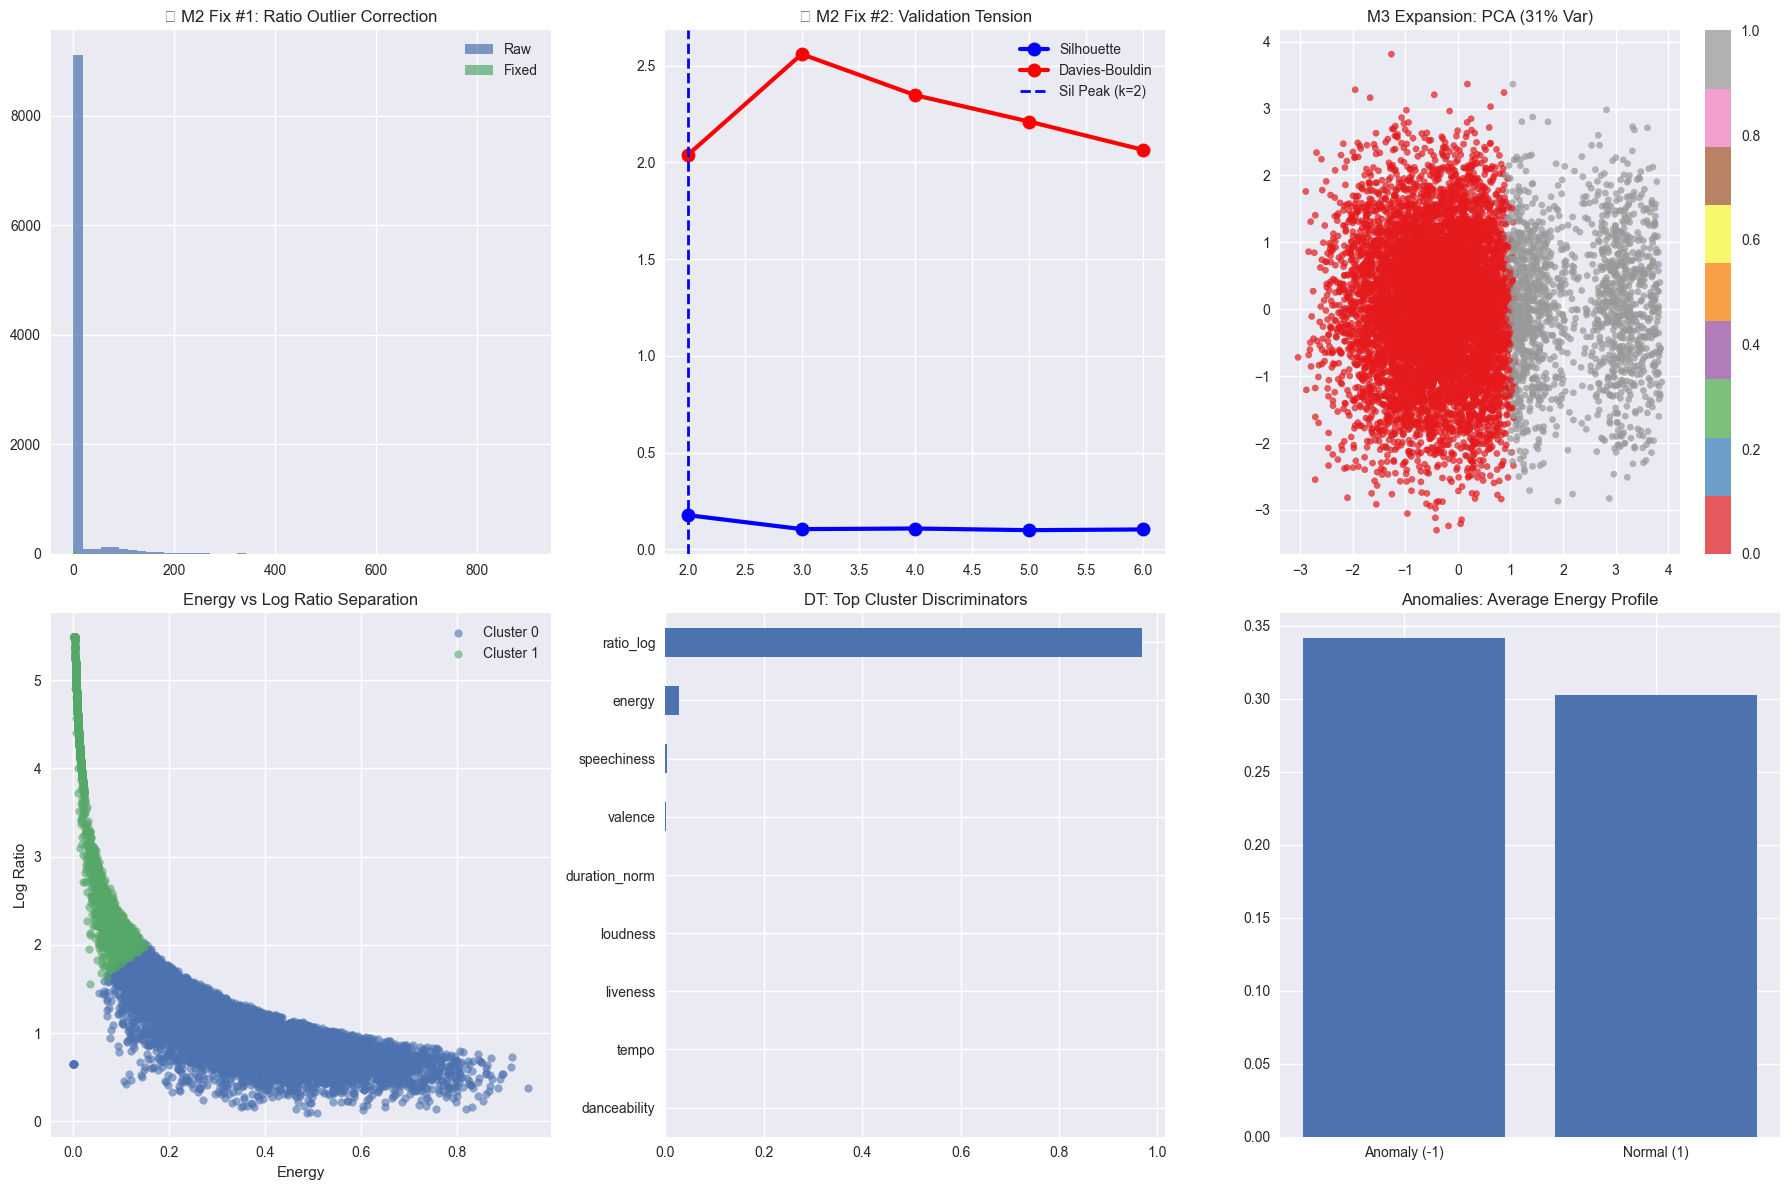


6. SAVING M3 DELIVERABLES...
✅ spotify_complete.csv saved successfully!


In [16]:
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(18,12))

# Plot 1: Ratio Fix
axes[0,0].hist(df['acoustic_electronic_ratio'], bins=50, alpha=0.7, label='Raw')
axes[0,0].hist(df['ratio_log'], bins=50, alpha=0.7, label='Fixed')
axes[0,0].set_title('✅ M2 Fix #1: Ratio Outlier Correction')
axes[0,0].legend()

# Plot 2: Validation Metrics
k_range = range(2,7)
axes[0,1].plot(k_range, sil_scores, 'bo-', linewidth=3, markersize=10, label='Silhouette')
axes[0,1].plot(k_range, db_scores, 'ro-', linewidth=3, markersize=10, label='Davies-Bouldin')
axes[0,1].axvline(k_opt_sil, color='b', ls='--', lw=2, label=f'Sil Peak (k={k_opt_sil})')
axes[0,1].set_title('✅ M2 Fix #2: Validation Tension')
axes[0,1].legend()

# Plot 3: PCA Clusters
scatter = axes[0,2].scatter(df_dedup['pca_1'], df_dedup['pca_2'],
                            c=df_dedup['cluster'], cmap='Set1', s=20, alpha=0.7)
axes[0,2].set_title(f'M3 Expansion: PCA ({pca.explained_variance_ratio_.sum():.0%} Var)')
plt.colorbar(scatter, ax=axes[0,2])

# Plot 4: Cluster Energy vs Ratio
for cluster in [0,1]:
    mask = df_dedup['cluster'] == cluster
    axes[1,0].scatter(df_dedup.loc[mask, 'energy'],
                     df_dedup.loc[mask, 'ratio_log'],
                     label=f'Cluster {cluster}', alpha=0.6, s=30)
axes[1,0].set_xlabel('Energy')
axes[1,0].set_ylabel('Log Ratio')
axes[1,0].set_title('Energy vs Log Ratio Separation')
axes[1,0].legend()

# Plot 5: Decision Tree Feature Importance
importances = pd.Series(dt.feature_importances_, index=features)
importances.sort_values().plot.barh(ax=axes[1,1])
axes[1,1].set_title('DT: Top Cluster Discriminators')

# Plot 6: Anomaly Detection
anomaly_means = df_dedup.groupby('anomaly')['energy'].mean()
axes[1,2].bar(['Anomaly (-1)', 'Normal (1)'], anomaly_means.values)
axes[1,2].set_title('Anomalies: Average Energy Profile')

plt.tight_layout()
plt.savefig('spotify_results.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. SAVE RESULTS

print("\n6. SAVING M3 DELIVERABLES...")
df_dedup.to_csv('spotify_complete.csv', index=False)
print("✅ spotify_complete.csv saved successfully!")
